In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

# s21 = pd.read_csv('data/raw/season_stats/S21.csv').sort_values(by='GAME_DATE')
# p21 = pd.read_csv('data/raw/playoff_stats/P21.csv').sort_values(by='GAME_DATE')
# s21 = pd.concat([s21, p21])

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])
s26.sample(10)

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,name
23698,23675,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501065,2026-03-26,SAC @ ORL,L,34.968333,8,12,0.667,6,10,0.600,1,2,0.500,1,2,3,0,0,0,0,0,5,3,23,-3,26.6,0,0,32.0,1,34:58,1,125.1,130.9,130.9,136.7,133.3,133.3,-11.6,-2.5,-2.5,0.000,0.0,0.0,0.029,0.087,0.053,0.0,0.0,0.917,0.893,0.154,0.165,95.04,94.03,78.36,94.03,0.096,68,8.0,12.0,NaN,4.33,2.76,2,2,4,46,1,0,29,2,2,1.000,6,10,0.600,2,2,1.000,45,88,0.511,14,33,0.424,13,16,0.813,9,26,35,30,11.0,7,3,2,24,14,117,-4.0,120.6,123.2,130.0,128.7,-9.4,-5.6,0.667,2.73,21.9,0.298,0.750,0.494,0.116,0.591,0.616,95.1,94.5,78.75,95,0.478,1610612753,ORL,Orlando Magic,40,74,0.541,13,27,0.481,28,32,0.875,7,29,36,22,12.0,2,2,3,14,24,121,4.0,130.0,128.7,120.6,123.2,9.4,5.6,0.550,1.83,17.6,0.250,0.702,0.506,0.128,0.628,0.687,95.1,94.5,78.75,94,0.522,0,SG,27.0,15.5,230.5,0,0.657738,0.000000,0.085792,0,4,NaN
553,370,2025-26,1629060,Rui Hachimura,Rui,1610612747,LAL,Los Angeles Lakers,22500019,2025-10-24,LAL vs. MIN,W,31.850000,10,13,0.769,2,4,0.500,1,2,0.500,1,1,2,0,0,0,0,0,1,2,23,11,25.4,0,0,27.0,1,31:51,1,142.9,142.2,142.2,126.9,123.1,123.1,16.0,19.1,19.1,0.000,0.0,0.0,0.053,0.032,0.040,0.0,0.0,0.846,0.829,0.188,0.202,95.49,97.21,81.00,97.21,0.124,64,10.0,13.0,F,4.22,2.11,1,3,4,29,0,0,16,3,3,1.000,7,10,0.700,2,4,0.500,45,76,0.592,12,29,0.414,26,32,0.813,7,31,38,26,12.0,6,3,3,20,27,128,18.0,134.6,137.6,116.7,117.0,17.9,20.6,0.578,2.17,20.3,0.265,0.627,0.482,0.129,0.671,0.710,94.7,93.5,77.92,93,0.614,1610612750,MIN,Minnesota Timberwolves,41,88,0.466,13,38,0.342,15,21,0.714,15,25,40,24,12.0,4,3,3,27,20,110,-18.0,116.7,117.0,134.6,137.6,-17.9,-20.6,0.585,2.00,17.5,0.373,0.735,0.518,0.128,0.540,0.566,94.7,93.5,77.92,94,0.386,0,PF,27.0,1.5,226.0,1,0.722135,0.000000,0.062794,1,1,NaN
6883,6801,2025-26,1641744,Zach Edey,Zach,1610612763,MEM,Memphis Grizzlies,22500322,2025-12-02,MEM @ SAS,L,29.668333,8,12,0.667,0,0,0.000,3,4,0.750,4,11,15,1,2,1,1,2,5,4,19,6,42.5,1,0,39.0,1,29:40,1,100.2,104.8,104.8,97.5,96.8,96.8,2.7,8.0,8.0,0.059,0.5,5.9,0.133,0.289,0.221,11.8,11.9,0.667,0.690,0.225,0.226,103.03,101.12,84.26,101.12,0.201,63,8.0,12.0,C,4.09,1.89,9,16,25,50,0,0,33,7,9,0.778,1,3,0.333,2,6,0.3

In [19]:
res = []
for df in [s22,s23,s24,s25,s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)

    df = ppm_features(df)

    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))

    df['PPM_L10_X_MIN_L10'] = df['PTS_PER_MIN_10_ewm'] * df['MIN_10_ewm']
    df['TS_PCT_X_USG_PCT'] = df['TS_PCT_season_avg'] * df['USG_PCT_season_avg']

    df['FGM_PER_MIN_X_OPP_FG%_ALLOWED'] = df['FGM_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['FGM_PER_MIN_X_OPP_DEF_RATING'] = df['FGM_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    df['FGA_PER_MIN_X_OPP_FG%_ALLOWED'] = df['FGA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['FGA_PER_MIN_X_OPP_DEF_RATING'] = df['FGA_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    df['UFGA_PER_MIN_X_OPP_FG%_ALLOWED'] = df['UFGA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['UFGA_PER_MIN_X_OPP_DEF_RATING'] = df['UFGA_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    df['USG_PCT_X_OPP_DEF_RATING'] = df['USG_PCT_roll10'] * df['OPP_DEF_RATING']


    df['CFGA_PER_MIN_X_OPP_FG%_ALLOWED'] = df['CFGA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['CFGA_PER_MIN_X_OPP_DEF_RATING'] = df['CFGA_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    df['CFG_PCT_X_OPP_FG%_ALLOWED'] = df['CFG_PCT_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']


    # df['DFGA_PER_MIN_X_OPP_FG%_ALLOWED'] = df['DFGA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    # df['DFGA_PER_MIN_X_OPP_DEF_RATING'] = df['DFGA_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    
    df['3PA_PER_MIN_X_OPP_FG3%_ALLOWED'] = df['3PA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG3%_ALLOWED']
    df['3PM_PER_MIN_X_OPP_FG3%_ALLOWED'] = df['3PM_PER_MIN_10_ewm'] * df['OPP_TEAM_FG3%_ALLOWED']
    df['FTA_PER_MIN_X_OPP_FTA_ALLOWED'] = df['FTA_PER_MIN_10_ewm'] * df['OPP_TEAM_FTA_ALLOWED']
    df['PTS_PER_MIN_X_OPP_PTS_ALLOWED'] = df['PTS_PER_MIN_10_ewm'] * df['OPP_TEAM_PTS_ALLOWED']
    df['POSS_PER_MIN_X_OPP_POSS_ALLOWED'] = df['POSS_PER_MIN_10_ewm'] * df['OPP_TEAM_POSS_ALLOWED']


    # --- Foul Drawing (PFD) ---
    df['FTA_PER_MIN_X_OPP_PFD_ALLOWED']     = df['FTA_PER_MIN_10_ewm']     * df['OPP_TEAM_PFD_ALLOWED']
    df['PTS_PER_MIN_X_OPP_PFD_ALLOWED']     = df['PTS_PER_MIN_10_ewm']     * df['OPP_TEAM_PFD_ALLOWED']

    # ---- TRENDS ---------
    df['PPM_TREND'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_20_ewm']

    player_stats = df.groupby('PLAYER_ID')['PTS_PER_MIN']
    df['PPM_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    df['PPM_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    std_dev = df['PPM_SEASON_STD']
    df['PPM_ROLE_Z_SCORE'] = np.where(
    std_dev > 0, 
    (df['PTS_PER_MIN_10_ewm'] - df['PPM_SEASON_MEAN']) / std_dev, 0)
    df["GP"] = df.groupby("PLAYER_ID").cumcount()

    le = LabelEncoder()
    df['PLAYER_ENCODED'] = le.fit_transform(df['PLAYER_ID'])
    df['POSITION_ENCODED'] = le.fit_transform(df['POS'])
    df['OPP_ENCODED'] = le.fit_transform(df['OPP_TEAM_ID'])
    df['TEAM_ENCODED'] = le.fit_transform(df['TEAM_ID'])

    df['MIN_REG'] = df['MIN'].clip(upper=48)
    df = df[(df['MIN_REG'] >= 10) | (df['STARTING'] == 1)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
df.sample(5)

The dataset has 120656 rows and 609 columns.


,Unnamed: 0.2,Unnamed: 0.1,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD_ODDS,GAME_TOTAL_ODDS,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,POSS_PER_MIN,FGA_PER_MIN,FGM_PER_MIN,3PA_PER_MIN,3PM_PER_MIN,FTA_PER_MIN,FTM_PER_MIN,TCHS_PER_MIN,PASS_PER_MIN,UFGA_PER_MIN,CFGA_PER_MIN,SAST_PER_MIN,DFGA_PER_MIN,MIN_roll5,PTS_roll5,USG_PCT_roll5,POSS_roll5,PTS_PER_MIN_roll5,POSS_PER_MIN_roll5,TS_PCT_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,FGM_PER_MIN_roll5,3PM_PER_MIN_roll5,FTM_PER_MIN_roll5,TCHS_PER_MIN_roll5,PASS_PER_MIN_roll5,UFGA_PER_MIN_roll5,CFGA_PER_MIN_roll5,SAST_PER_MIN_roll5,UFG_PCT_roll5,CFG_PCT_roll5,FG_PCT_roll5,FG3_PCT_roll5,FT_PCT_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,POSS_roll10,PTS_PER_MIN_roll10,POSS_PER_MIN_roll10,TS_PCT_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,FGM_PER_MIN_roll10,3PM_PER_MIN_roll10,FTM_PER_MIN_roll10,TCHS_PER_MIN_roll10,PASS_PER_MIN_roll10,UFGA_PER_MIN_roll10,CFGA_PER_MIN_roll10,SAST_PER_MIN_roll10,UFG_PCT_roll10,CFG_PCT_roll10,FG_PCT_roll10,FG3_PCT_roll10,FT_PCT_roll10,MIN_roll20,PTS_roll20,USG_PCT_roll20,POSS_roll20,PTS_PER_MIN_roll20,POSS_PER_MIN_roll20,TS_PCT_roll20,FGA_PER_MIN_roll20,3PA_PER_MIN_roll20,FTA_PER_MIN_roll20,FGM_PER_MIN_roll20,3PM_PER_MIN_roll20,FTM_PER_MIN_roll20,TCHS_PER_MIN_roll20,PASS_PER_MIN_roll20,UFGA_PER_MIN_roll20,CFGA_PER_MIN_roll20,SAST_PER_MIN_roll20,UFG_PCT_roll20,CFG_PCT_roll20,FG_PCT_roll20,FG3_PCT_roll20,FT_PCT_roll20,MIN_5_ewm,PTS_5_ewm,USG_PCT_5_ewm,POSS_5_ewm,PTS_PER_MIN_5_ewm,POSS_PER_MIN_5_ewm,TS_PCT_5_ewm,FGA_PER_MIN_5_ewm,3PA_PER_MIN_5_ewm,FTA_PER_MIN_5_ewm,FGM_PER_MIN_5_ewm,3PM_PER_MIN_5_ewm,FTM_PER_MIN_5_ewm,TCHS_PER_MIN_5_ewm,PASS_PER_MIN_5_ewm,UFGA_PER_MIN_5_ewm,CFGA_PER_MIN_5_ewm,SAST_PER_MIN_5_ewm,UFG_PCT_5_ewm,CFG_PCT_5_ewm,FG_PCT_5_ewm,FG3_PCT_5_ewm,FT_PCT_5_ewm,DFGA_PER_MIN_5_ewm,MIN_10_ewm,PTS_10_ewm,USG_PCT_10_ewm,POSS_10_ewm,PTS_PER_MIN_10_ewm,POSS_PER_MIN_10_ewm,TS_PCT_10_ewm,FGA_PER_MIN_10_ewm,3PA_PER_MIN_10_ewm,FTA_PER_MIN_10_ewm,FGM_PER_MIN_10_ewm,3PM_PER_MIN_10_ewm,FTM_PER_MIN_10_ewm,TCHS_PER_MIN_10_ewm,PASS_PER_MIN_10_ewm,UFGA_PER_MIN_10_ewm,CFGA_PER_MIN_10_ewm,SAST_PER_MIN_10_ewm,UFG_PCT_10_ewm,CFG_PCT_10_ewm,FG_PCT_10_ewm,FG3_PCT_10_ewm,FT_PCT_10_ewm,DFGA_PER_MIN_10_ewm,MIN_15_ewm,PTS_15_ewm,USG_PCT_15

In [ ]:
# df.to_csv('data/processed/training/S26_TRAINING_PPM.csv', index=False)

In [26]:
PPM_FEATURES = [
    # 'UFGA_PER_MIN_X_OPP_DEF_RATING',
    # 'CFGA_PER_MIN_X_OPP_DEF_RATING',
    # 'PPM_SEASON_MEAN',
    # 'TEAM_USG_RANK_L10',
    # 'PTS_PER_MIN_X_OPP_PTS_ALLOWED',
    # 'TS_PCT_X_USG_PCT',
    # 'FT_PCT_season_avg',
    # 'PTS_season_avg',
    # 'IS_PLAYOFF',

    # new featues im trying out
    'ACTIVE_STARS_COUNT',
    'STARTING',
    'IS_PLAYOFF',
    'POSITION_ENCODED',

    'PTS_PER_MIN_5_ewm',
    'PTS_PER_MIN_roll5',
    'PTS_PER_MIN_20_ewm',
    'PTS_PER_MIN_roll20',
    'PPM_TREND',
    'PTS_PER_MIN_std10', 
    'UFGA_PER_MIN_X_OPP_DEF_RATING',
    # 'CFGA_PER_MIN_X_OPP_DEF_RATING',
    'PTS_PER_MIN_X_OPP_PTS_ALLOWED',
    'HOME_AVG_PTS_PER_MIN_TO_DATE',
    'AWAY_AVG_PTS_PER_MIN_TO_DATE', 
    # 'TS_PCT_X_USG_PCT',
    'USG_PCT_X_OPP_DEF_RATING',


]

In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[PPM_FEATURES]
y = ppm_df["PTS_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
#Best params: {'n_estimators': 1344, 'max_depth': 3, 'learning_rate': 0.0199208375412252, 'subsample': 0.6525095024077675, 'colsample_bytree': 0.7424913081435832, 'reg_alpha': 3.890568820995351, 'reg_lambda': 0.007402304793152013, 'min_child_weight': 10}
XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1344,
    max_depth          = 3,
    learning_rate      = 0.0199208375412252,
    subsample          = 0.6525095024077675,
    colsample_bytree   = 0.7424913081435832,
    reg_alpha          = 3.890568820995351,
    reg_lambda         = 4.755281357016035,
    min_child_weight   = 10,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Data shape: {X.shape}")
tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Data shape: (120656, 15)
TSCV fold 1                    | MAE: 0.161 | R²: 0.311 | 80% Coverage: 79.5%
TSCV fold 2                    | MAE: 0.159 | R²: 0.331 | 80% Coverage: 79.7%
TSCV fold 3                    | MAE: 0.161 | R²: 0.301 | 80% Coverage: 79.4%
TSCV fold 4                    | MAE: 0.164 | R²: 0.286 | 80% Coverage: 79.1%
TSCV fold 5                    | MAE: 0.164 | R²: 0.303 | 80% Coverage: 79.3%

TimeSeriesSplit Summary
  MAE      : 0.162 ± 0.002
  R²       : 0.306  ± 0.015
  Coverage : 79.4% ± 0.2%  (target ~80%)


In [6]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# # Uses X, y, TimeSeriesSplit from your Phase 1 cell
# tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

In [28]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")   

WF fold 1 (2024-01-12 00:00:00 → 2024-04-24 00:00:00) | MAE: 0.159 | R²: 0.313 | 80% Coverage: 79.8%
WF fold 2 (2024-04-24 00:00:00 → 2025-01-17 00:00:00) | MAE: 0.163 | R²: 0.293 | 80% Coverage: 79.2%
WF fold 3 (2025-01-17 00:00:00 → 2025-05-08 00:00:00) | MAE: 0.162 | R²: 0.291 | 80% Coverage: 78.9%
WF fold 4 (2025-05-08 00:00:00 → 2026-01-17 00:00:00) | MAE: 0.166 | R²: 0.294 | 80% Coverage: 79.2%

Walk-Forward Summary
  MAE      : 0.162 ± 0.002
  R²       : 0.298  ± 0.009
  Coverage : 79.3% ± 0.3%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2024-01-12 00:00:00 → 2024-04-24 00:00:00) 0.159  
  WF fold 2 (2024-04-24 00:00:00 → 2025-01-17 00:00:00) 0.163  
  WF fold 3 (2025-01-17 00:00:00 → 2025-05-08 00:00:00) 0.162  
  WF fold 4 (2025-05-08 00:00:00 → 2026-01-17 00:00:00) 0.166  


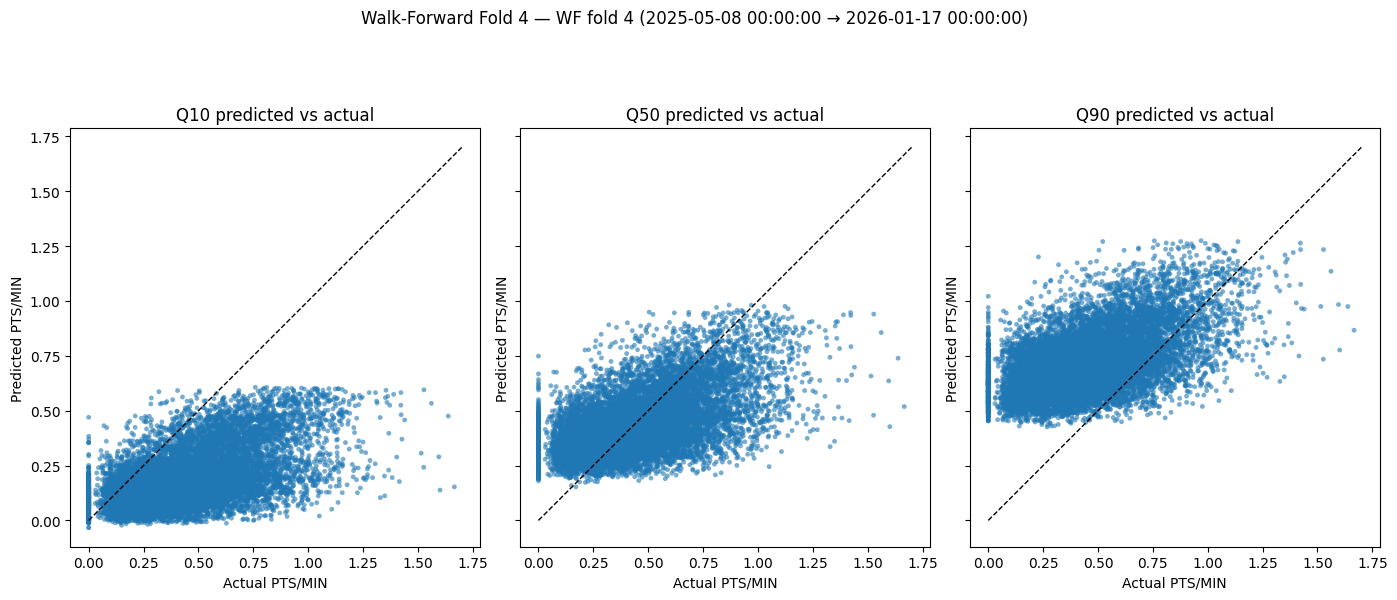

Coverage per quantile (should match quantile value):
  Q10: 10.3%  (target 10%, delta +0.3%)
  Q50: 50.1%  (target 50%, delta +0.1%)
  Q90: 89.5%  (target 90%, delta -0.5%)

80% interval width (Q10→Q90):
  mean : 0.53 min
  median: 0.52 min
  std  : 0.06 min


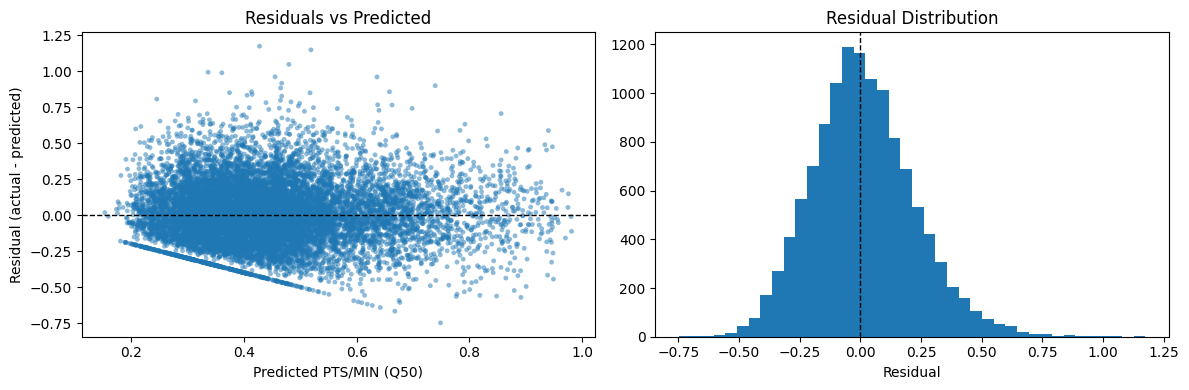


Residual summary:
  mean bias : +0.012 min  (close to 0 = unbiased)
  std       : 0.212 min


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/MIN")
    ax.set_ylabel("Predicted PTS/MIN")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted PTS/MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

In [30]:
ppm_df = df[PPM_FEATURES + ["MIN", "GAME_DATE", "PLAYER_NAME"]].sort_values("GAME_DATE").reset_index(drop=True)

val_df = ppm_df.iloc[train_end:val_end].reset_index(drop=True)

player_col = "PLAYER_NAME" if "PLAYER_NAME" in val_df.columns else None
if player_col is None:
    raise ValueError("Add PLAYER_NAME to ppm_df columns (see comment above).")

pred50 = np.asarray(pred_mid).reshape(-1)
pred90 = np.asarray(pred_high).reshape(-1)
out = pd.DataFrame({
    "player": val_df[player_col].values,
    "actual_ppm": np.asarray(y_true).reshape(-1),
    "pred_ppm_q50": pred50,
    "pred_ppm_q90": pred90,
})
out["error"] = out["actual_ppm"] - out["pred_ppm_q50"]
out["abs_error"] = out["error"].abs()

# optional: tie-break sort
if "GAME_DATE" in val_df.columns:
    out["game_date"] = val_df["GAME_DATE"].values

print(out.sort_values("abs_error", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.3f} | RMSE: {np.sqrt((out['error']**2).mean()):.3f}")

                 player  actual_ppm  pred_ppm_q50  pred_ppm_q90     error  abs_error  game_date
            Jalen Suggs    0.530638      0.530621      0.782245  0.000017   0.000017 2025-11-12
        Jaden McDaniels    0.340771      0.340753      0.592167  0.000018   0.000018 2025-05-14
      Jarred Vanderbilt    0.265096      0.264993      0.535115  0.000103   0.000103 2025-11-14
           John Konchar    0.203476      0.203365      0.492898  0.000111   0.000111 2025-11-22
  Giannis Antetokounmpo    0.806885      0.806773      1.082986  0.000113   0.000113 2026-01-13
     Walter Clayton Jr.    0.337711      0.337829      0.622689 -0.000118   0.000118 2025-11-10
          Dyson Daniels    0.356853      0.356989      0.579991 -0.000136   0.000136 2026-01-11
        Bilal Coulibaly    0.443182      0.443364      0.709846 -0.000182   0.000182 2025-11-19
         Day'Ron Sharpe    0.446650      0.446446      0.716639  0.000204   0.000204 2025-12-12
            Josh Minott    0.316027     


── q_0.10 ──


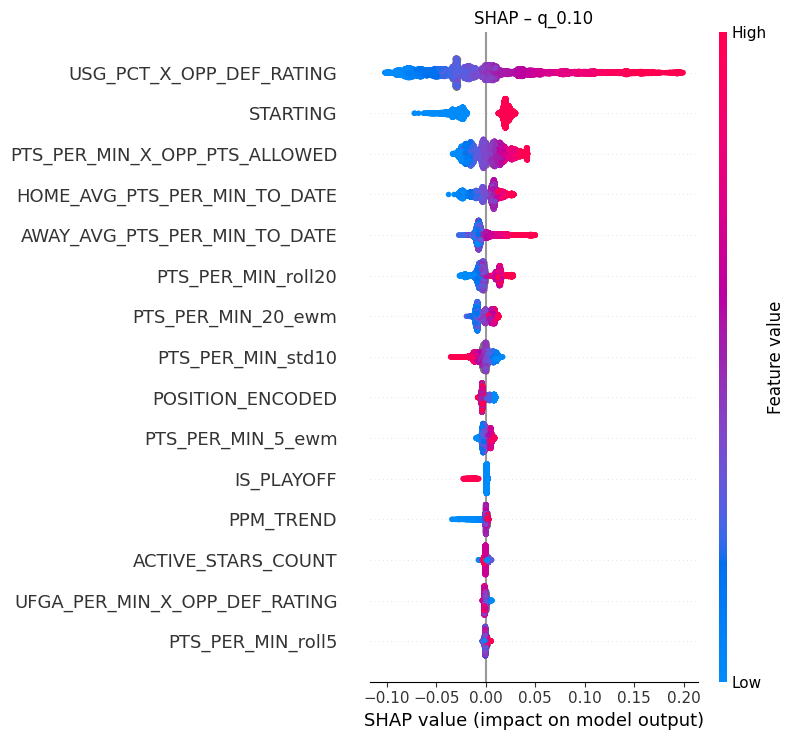


── q_0.50 ──


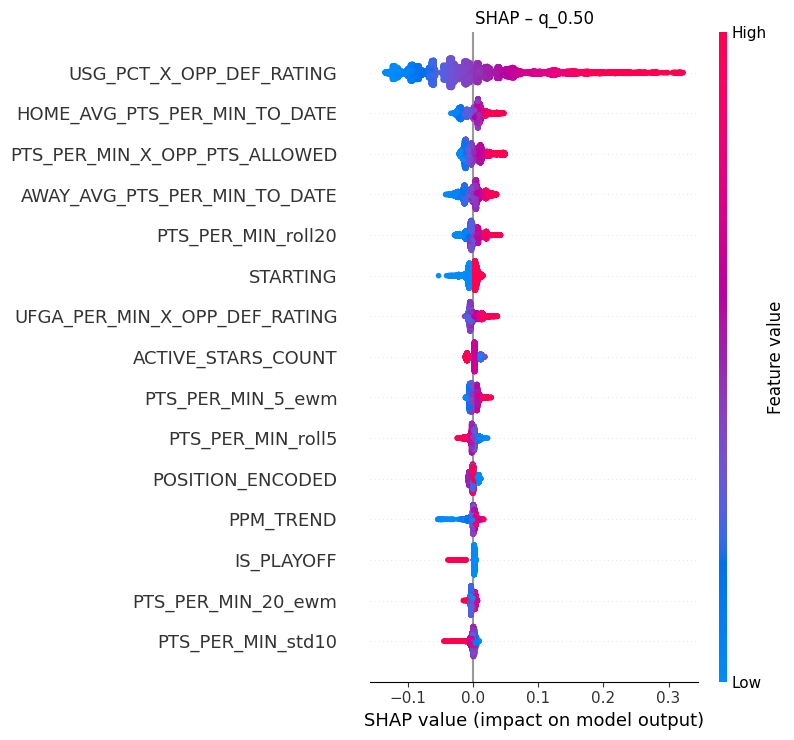


── q_0.90 ──


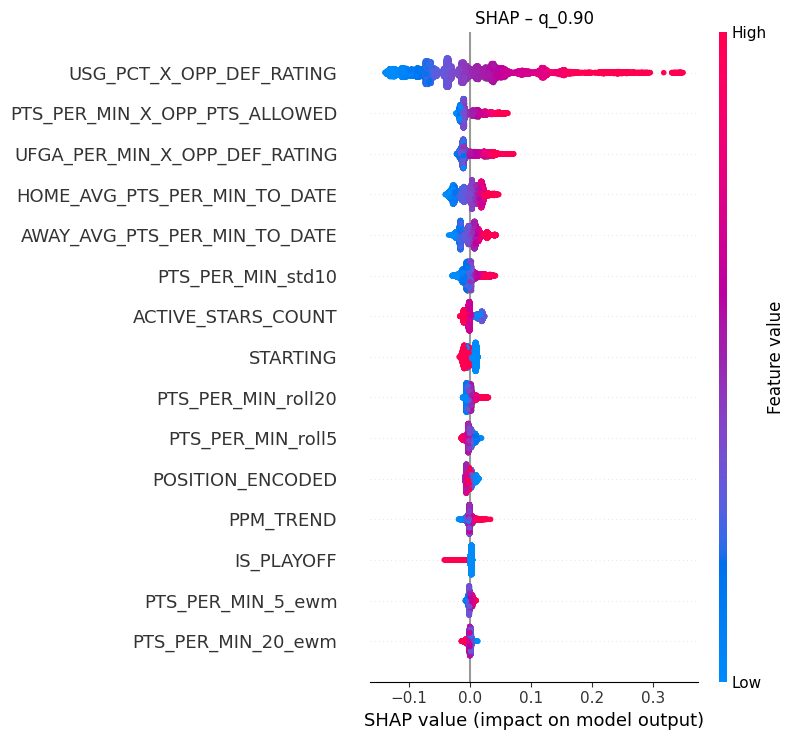

In [31]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

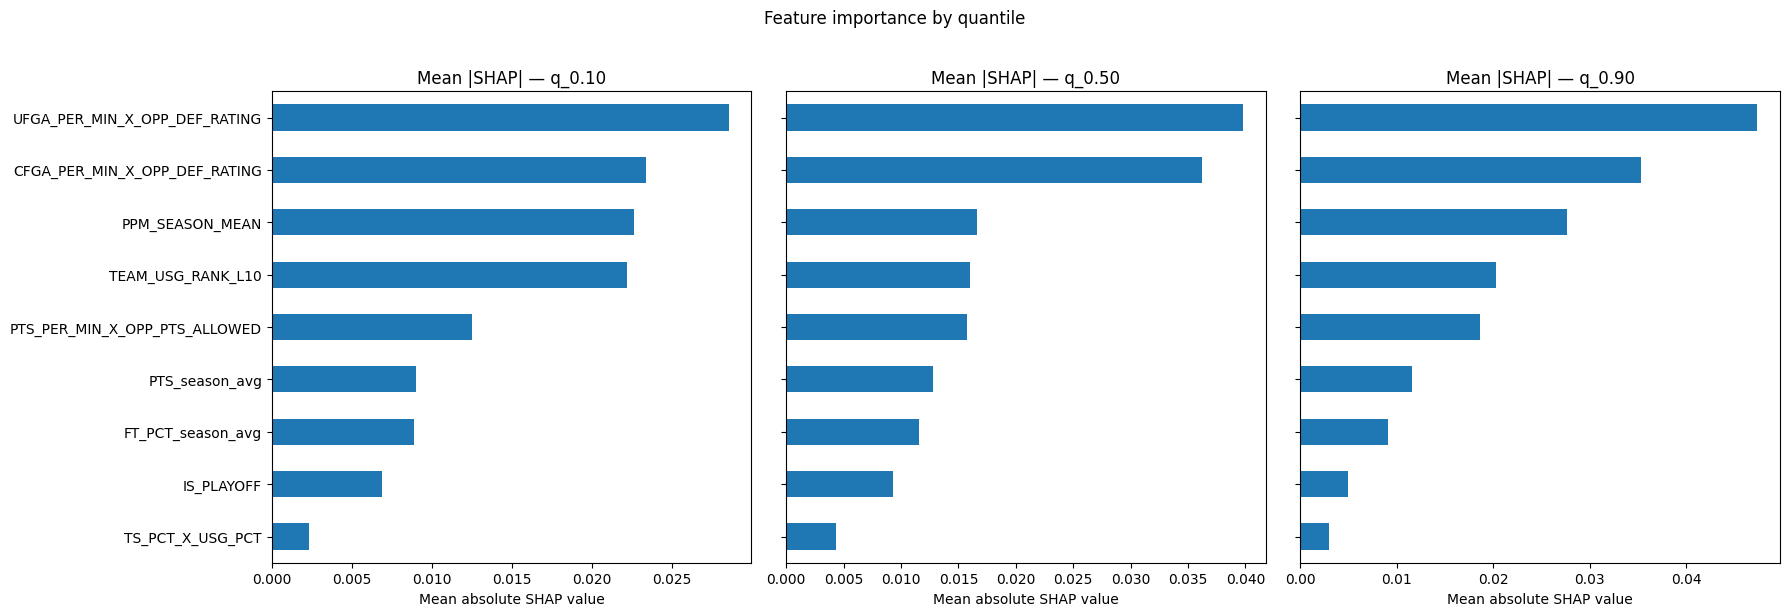

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (q_key, model) in zip(axes, models_last.items()):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feat_imp      = pd.Series(mean_abs_shap, index=PPM_FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=ax)
    ax.set_title(f"Mean |SHAP| — {q_key}")
    ax.set_xlabel("Mean absolute SHAP value")

plt.suptitle("Feature importance by quantile", y=1.02)
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_tr,
    y_tr,
    n_repeats=30,
    random_state=42
)

pi_df = (
    pd.DataFrame({
        'feature':    X_tr.columns,
        'importance': result.importances_mean,
        'std':        result.importances_std,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

pi_df.index += 1  # rank starts at 1
pi_df['importance'] = pi_df['importance'].round(5)
pi_df['std']        = pi_df['std'].round(5)

print(pi_df.to_string())

                          feature  importance      std
1        USG_PCT_X_OPP_DEF_RATING     0.22481  0.00228
2   UFGA_PER_MIN_X_OPP_DEF_RATING     0.04543  0.00066
3    HOME_AVG_PTS_PER_MIN_TO_DATE     0.02605  0.00052
4               PTS_PER_MIN_roll5     0.01874  0.00025
5   PTS_PER_MIN_X_OPP_PTS_ALLOWED     0.01452  0.00039
6              ACTIVE_STARS_COUNT     0.00763  0.00027
7                       PPM_TREND     0.00680  0.00021
8               PTS_PER_MIN_5_ewm     0.00617  0.00010
9                      IS_PLAYOFF     0.00596  0.00024
10              PTS_PER_MIN_std10     0.00311  0.00040
11             PTS_PER_MIN_roll20     0.00064  0.00015
12             PTS_PER_MIN_20_ewm     0.00045  0.00011
13   AWAY_AVG_PTS_PER_MIN_TO_DATE    -0.00064  0.00043
14               POSITION_ENCODED    -0.00077  0.00024
15                       STARTING    -0.02401  0.00043


In [ ]:
baseline_rmse = evaluate(model, all_features)

for feature in features:
    ablated_rmse = evaluate(model, all_features_except(feature))
    delta = ablated_rmse - baseline_rmse
    
    # Positive delta = feature was helping
    # Zero/negative delta = feature is useless or hurting

In [ ]:
# Check: does the model systematically over/underproject
# for specific player types?

errors_by_usage_bucket = df.groupby(
    pd.qcut(df['usage_rate'], 5)
)['prediction_error'].mean()

# If high-usage players are consistently underprojected
# your usage encoding is wrong regardless of what SHAP says

In [11]:
explainer_low  = shap.TreeExplainer(models_last["q_0.10"])
explainer_high = shap.TreeExplainer(models_last["q_0.90"])

shap_low  = explainer_low(X_val_last).values
shap_high = explainer_high(X_val_last).values

divergence = pd.Series(
    np.abs(shap_high - shap_low).mean(axis=0),
    index=PPM_FEATURES
).sort_values(ascending=False)

print("\nFeatures driving Q10 vs Q90 spread (uncertainty drivers):")
print(divergence.head(10).to_string())


Features driving Q10 vs Q90 spread (uncertainty drivers):
PTS_season_avg                   0.028484
UFGA_PER_MIN_X_OPP_DEF_RATING    0.025233
PPM_SEASON_MEAN                  0.021934
PTS_PER_MIN_X_OPP_PTS_ALLOWED    0.011354
TEAM_USG_RANK_L10                0.009311
CFGA_PER_MIN_X_OPP_DEF_RATING    0.009213
TS_PCT_X_USG_PCT                 0.007042
FT_PCT_season_avg                0.005815
IS_PLAYOFF                       0.002608


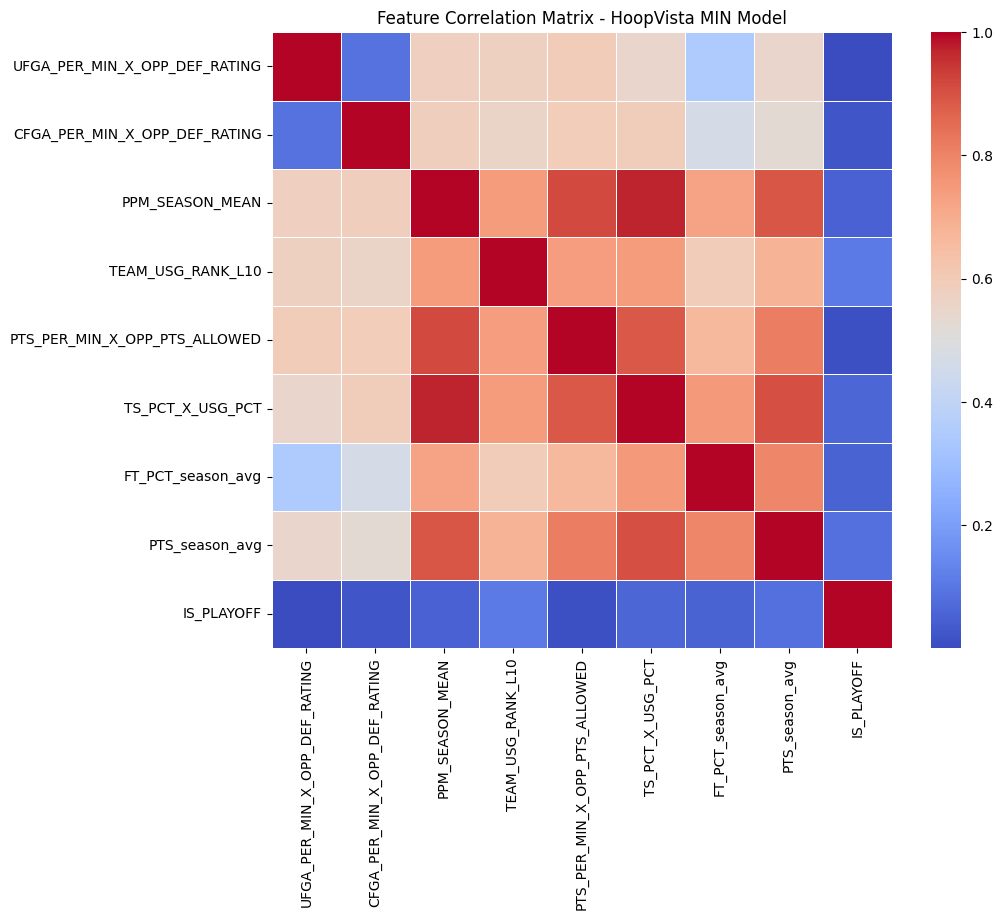

--- High Correlation Report (Threshold > 0.95) ---
TS_PCT_X_USG_PCT <-> PPM_SEASON_MEAN: 0.9698


['TS_PCT_X_USG_PCT']

In [12]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [13]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   PPM_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"ppm_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_ppm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to ppm_quantile_xgb_2026-01-01.joblib
Loaded model MAE: 0.162
Trained on data up to: 2025-03-19 00:00:00
Validated on data up to: 2026-01-01 00:00:00
